In [1]:
import time
import os

import pandas as pd
import numpy as np
np.set_printoptions(precision=6, suppress=True)

from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras import *
tf.__version__

'2.0.0'

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

2 Physical GPUs, 2 Logical GPUs


In [3]:
from tensorflow.keras.metrics import Metric
class RSquare(Metric):
    """Compute R^2 score.
     This is also called as coefficient of determination.
     It tells how close are data to the fitted regression line.
     - Highest score can be 1.0 and it indicates that the predictors
       perfectly accounts for variation in the target.
     - Score 0.0 indicates that the predictors do not
       account for variation in the target.
     - It can also be negative if the model is worse.
     Usage:
     ```python
     actuals = tf.constant([1, 4, 3], dtype=tf.float32)
     preds = tf.constant([2, 4, 4], dtype=tf.float32)
     result = tf.keras.metrics.RSquare()
     result.update_state(actuals, preds)
     print('R^2 score is: ', r1.result().numpy()) # 0.57142866
    ```
    """

    def __init__(self, name='r_square', dtype=tf.float32):
        super(RSquare, self).__init__(name=name, dtype=dtype)
        self.squared_sum = self.add_weight("squared_sum", initializer="zeros")
        self.sum = self.add_weight("sum", initializer="zeros")
        self.res = self.add_weight("residual", initializer="zeros")
        self.count = self.add_weight("count", initializer="zeros")

    def update_state(self, y_true, y_pred):
        y_true = tf.convert_to_tensor(y_true, tf.float32)
        y_pred = tf.convert_to_tensor(y_pred, tf.float32)
        self.squared_sum.assign_add(tf.reduce_sum(y_true**2))
        self.sum.assign_add(tf.reduce_sum(y_true))
        self.res.assign_add(
            tf.reduce_sum(tf.square(tf.subtract(y_true, y_pred))))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        mean = self.sum / self.count
        total = self.squared_sum - 2 * self.sum * mean + self.count * mean**2
        return 1 - (self.res / total)

    def reset_states(self):
        # The state of the metric will be reset at the start of each epoch.
        self.squared_sum.assign(0.0)
        self.sum.assign(0.0)
        self.res.assign(0.0)
        self.count.assign(0.0)

In [4]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

# Model training

## hyperparameters

In [6]:
BEST_PATH = './models/best_Unet.h5'
TRAINING_EPOCHS = 500
BATCH_SIZE = 32
LEARNING_RATE = 0.001

## data loading

In [7]:
l = np.load('./data/pap_dataset.npz')
raw_input = l['raw_input']
raw_label = l['raw_label']
test_input = l['test_input']
test_label = l['test_label']
MAXS = l['MAXS']
MINS = l['MINS']

SCREEN_SIZE = l['SCREEN_SIZE']

In [8]:
print(raw_input.shape)
print(raw_label.shape)

(58764, 10, 10, 4)
(58764, 10, 10, 1)


In [9]:
print(test_input.shape)
print(test_label.shape)

(32135, 10, 10, 4)
(32135, 10, 10, 1)


In [10]:
num_train = int(raw_input.shape[0]*.7)
raw_input, raw_label = shuffle(raw_input, raw_label, random_state=4574)
train_input, train_label = raw_input[:num_train, ...], raw_label[:num_train, ...]
val_input, val_label = raw_input[num_train:, ...], raw_label[num_train:, ...]

In [11]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_input, train_label)).repeat()
train_dataset = train_dataset.cache().shuffle(BATCH_SIZE*50).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices((val_input, val_label))
val_dataset = val_dataset.cache().shuffle(BATCH_SIZE*50).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((test_input, test_label))
test_dataset = test_dataset.batch(BATCH_SIZE)

In [12]:
expected_input = Input(raw_input.shape[1:])

#convolution 1
conv1 = layers.Conv2D(32, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(expected_input)
conv1 = layers.BatchNormalization()(conv1)
conv1 = layers.Dropout(0.1)(conv1)
conv1 = layers.Conv2D(32, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(conv1)
conv1 = layers.BatchNormalization()(conv1)
pool1 = layers.MaxPooling2D()(conv1)

#convolution 2
conv2 = layers.Conv2D(64, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(pool1)
conv2 = layers.BatchNormalization()(conv2)
conv2 = layers.Dropout(0.2)(conv2)
conv2 = layers.Conv2D(64, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(conv2)
conv2 = layers.BatchNormalization()(conv2)
pool2 = layers.MaxPooling2D()(conv2)

#convolution 3
bottom = layers.Conv2D(128, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(pool2)
bottom = layers.BatchNormalization()(bottom)
bottom = layers.Dropout(0.2)(bottom)
bottom = layers.Conv2D(128, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(bottom)
bottom = layers.BatchNormalization()(bottom)

#convolution.T 1
deconv1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(bottom)
deconv1 = layers.ZeroPadding2D(((1, 0),(0, 1)))(deconv1) # (top, bottom), (left, right)
deconv1 = layers.concatenate([deconv1, conv2])
deconv1 = layers.Conv2D(64, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(deconv1)
deconv1 = layers.BatchNormalization()(deconv1)
deconv1 = layers.Dropout(0.2)(deconv1)
deconv1 = layers.Conv2D(64, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(deconv1)
deconv1 = layers.BatchNormalization()(deconv1)

#convolution.T 2
deconv2 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(deconv1)
deconv2 = layers.concatenate([deconv2, conv1])
deconv2 = layers.Conv2D(32, (2, 2), activation='relu', kernel_initializer='he_normal', padding='same')(deconv2)
deconv2 = layers.BatchNormalization()(deconv2)
deconv2 = layers.Dropout(0.1)(deconv2)
deconv2 = layers.Conv2D(32, (1, 1), activation='relu', kernel_initializer='he_normal', padding='same')(deconv2)
deconv2 = layers.BatchNormalization()(deconv2)

expected_output = outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(deconv2)


In [ ]:
#loss should be de-masked.
loss_object = tf.keras.losses.MeanSquaredError()
def loss_function(real, pred):
    
    loss_ = loss_object(real, pred)
    return tf.reduce_mean(loss_)
pred_result[0, ..., 0] * (1 - test_input[0, ..., 1])

In [13]:
Unet = Model(inputs=[expected_input], outputs=[expected_output])
Unet.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                   loss = tf.keras.losses.MeanSquaredError())
Unet.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 10, 10, 4)]  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 10, 10, 32)   544         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 10, 10, 32)   128         conv2d[0][0]                     
__________________________________________________________________________________________________
dropout (Dropout)               (None, 10, 10, 32)   0           batch_normalization[0][0]        
______________________________________________________________________________________________

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_PATH,
        # Path where to save the model
        # The two parameters below mean that we will overwrite
        # the current checkpoint if and only if
        # the `val_loss` score has improved.
        save_best_only=True,
        monitor='val_loss',
        verbose=1),
    tf.keras.callbacks.EarlyStopping(
  monitor='val_loss', min_delta=0.0001,  patience=40)
]

In [15]:
Unet.fit(
    train_dataset, epochs = TRAINING_EPOCHS,
    steps_per_epoch = 144,
    callbacks=callbacks,
    validation_data = test_dataset, validation_steps = 50)

Train for 144 steps, validate for 50 steps
Epoch 1/500
141/144 [============================>.] - ETA: 0s - loss: 0.0298
Epoch 00001: val_loss improved from inf to 0.01368, saving model to ./models/best_Unet.h5
144/144 [==============================] - 6s 44ms/step - loss: 0.0295 - val_loss: 0.0137
Epoch 2/500
141/144 [============================>.] - ETA: 0s - loss: 0.0100
Epoch 00002: val_loss improved from 0.01368 to 0.00798, saving model to ./models/best_Unet.h5
144/144 [==============================] - 2s 17ms/step - loss: 0.0099 - val_loss: 0.0080
Epoch 3/500
141/144 [============================>.] - ETA: 0s - loss: 0.0070
Epoch 00003: val_loss improved from 0.00798 to 0.00537, saving model to ./models/best_Unet.h5
144/144 [==============================] - 2s 17ms/step - loss: 0.0069 - val_loss: 0.0054
Epoch 4/500
142/144 [============================>.] - ETA: 0s - loss: 0.0057
Epoch 00004: val_loss improved from 0.00537 to 0.00459, saving model to ./models/best_Unet.h5
144

# Model evaluation

In [16]:
trained_Unet = tf.keras.models.load_model(BEST_PATH)

In [17]:
test_loss = trained_Unet.evaluate(test_dataset)

1005/1005 [==============================] - 6s 6ms/step - loss: 0.0011


In [18]:
pred_result = trained_Unet.predict(test_dataset)

In [19]:
print(pred_result.shape)
print(test_label.shape)

(32135, 10, 10, 1)
(32135, 10, 10, 1)


In [37]:
test_input[0, ..., 1]

array([[1., 1., 0., 1., 0., 0., 0., 1., 0., 0.],
       [0., 1., 0., 1., 1., 1., 1., 1., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 1., 0., 0., 1., 1., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 0., 0., 1., 0., 0., 0., 1., 0.]])

In [36]:
pred_result[0, ..., 0] * (1 - test_input[0, ..., 1])

array([[0.      , 0.      , 0.635345, 0.      , 0.14331 , 0.283904,
        0.367319, 0.      , 0.212426, 0.171652],
       [0.313069, 0.      , 0.666692, 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.202383, 0.      ],
       [0.367481, 0.411782, 0.663633, 0.176398, 0.344056, 0.356095,
        0.410759, 0.639917, 0.198587, 0.366542],
       [0.349929, 0.423509, 0.      , 0.171445, 0.      , 0.      ,
        0.425678, 0.      , 0.      , 0.      ],
       [0.335121, 0.433521, 0.700186, 0.174808, 0.280678, 0.335244,
        0.424462, 0.700239, 0.187764, 0.13139 ],
       [0.      , 0.      , 0.702724, 0.      , 0.123936, 0.298484,
        0.      , 0.      , 0.      , 0.      ],
       [0.26985 , 0.      , 0.      , 0.204781, 0.029487, 0.260421,
        0.389847, 0.      , 0.      , 0.025828],
       [0.271725, 0.388859, 0.589424, 0.205137, 0.016504, 0.258933,
        0.376025, 0.590588, 0.206266, 0.016066],
       [0.      , 0.      , 0.      , 0.      , 0.      , 0.    

In [29]:
pred_result[0, ..., 0]

array([[0.28992 , 0.362144, 0.635345, 0.218828, 0.14331 , 0.283904,
        0.367319, 0.639046, 0.212426, 0.171652],
       [0.313069, 0.387077, 0.666692, 0.181664, 0.261183, 0.302185,
        0.38706 , 0.653584, 0.202383, 0.246205],
       [0.367481, 0.411782, 0.663633, 0.176398, 0.344056, 0.356095,
        0.410759, 0.639917, 0.198587, 0.366542],
       [0.349929, 0.423509, 0.66464 , 0.171445, 0.34479 , 0.367261,
        0.425678, 0.658846, 0.185532, 0.32332 ],
       [0.335121, 0.433521, 0.700186, 0.174808, 0.280678, 0.335244,
        0.424462, 0.700239, 0.187764, 0.13139 ],
       [0.301545, 0.419993, 0.702724, 0.183686, 0.123936, 0.298484,
        0.412958, 0.724943, 0.1796  , 0.095767],
       [0.26985 , 0.404758, 0.681461, 0.204781, 0.029487, 0.260421,
        0.389847, 0.681475, 0.188858, 0.025828],
       [0.271725, 0.388859, 0.589424, 0.205137, 0.016504, 0.258933,
        0.376025, 0.590588, 0.206266, 0.016066],
       [0.260486, 0.371491, 0.503103, 0.206656, 0.005982, 0.2559

In [30]:
test_label[0, ..., 0]

array([[0.289952, 0.362451, 0.660613, 0.219782, 0.242619, 0.289952,
        0.362451, 0.660613, 0.219782, 0.242619],
       [0.303874, 0.401407, 0.669486, 0.183697, 0.254131, 0.303874,
        0.401407, 0.669486, 0.183697, 0.254131],
       [0.328692, 0.421315, 0.682102, 0.187987, 0.282942, 0.328692,
        0.421315, 0.682102, 0.187987, 0.282942],
       [0.378733, 0.434872, 0.684181, 0.184294, 0.348088, 0.378733,
        0.434872, 0.684181, 0.184294, 0.348088],
       [0.375504, 0.449803, 0.689727, 0.190716, 0.295057, 0.375504,
        0.449803, 0.689727, 0.190716, 0.295057],
       [0.305085, 0.433156, 0.756967, 0.177738, 0.104612, 0.305085,
        0.433156, 0.756967, 0.177738, 0.104612],
       [0.273406, 0.417539, 0.713018, 0.17642 , 0.043953, 0.273406,
        0.417539, 0.713018, 0.17642 , 0.043953],
       [0.282889, 0.393856, 0.472896, 0.188805, 0.00434 , 0.282889,
        0.393856, 0.472896, 0.188805, 0.00434 ],
       [0.256255, 0.375837, 0.503813, 0.201656, 0.00434 , 0.2562

In [20]:
for _ in range(test_label.shape[-2]):
    print(np.sqrt(mean_squared_error(test_label[..., _, 0].reshape(-1), pred_result[..., _, 0].reshape(-1))))

0.020953374087860983
0.02006559058796731
0.03300976998245088
0.01618180276423654
0.0400429869778902
0.022114433282411475
0.02233217013339263
0.038612506014105784
0.018589890228308148
0.06734886334546017


In [23]:
r2 = RSquare()
for _ in range(test_label.shape[-1]):
    r2.reset_states()
    print(r2(tf.cast(test_label[..., _, 0].reshape(-1), tf.float32), tf.cast(pred_result[..., _, 0].reshape(-1), tf.float32)))

tf.Tensor(0.9590551, shape=(), dtype=float32)


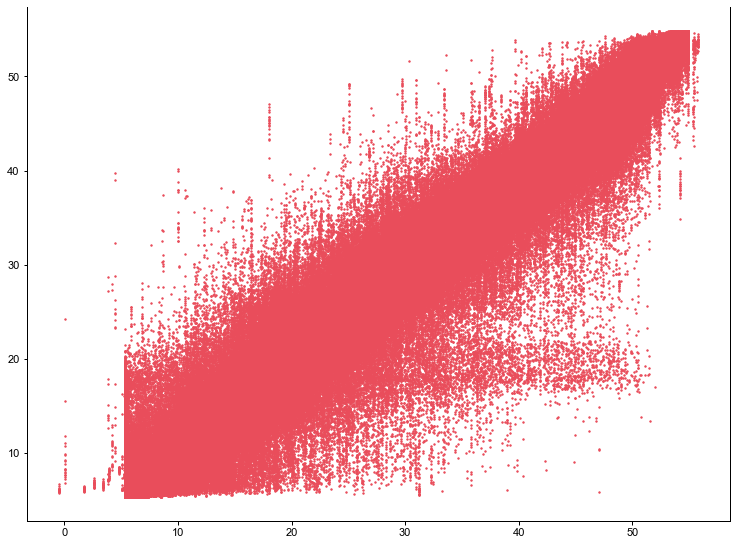

In [26]:
fig = plt.figure(figsize=((8/2.54)*4, (6/2.54)*4))
plt.scatter(tf.cast(tf.reshape(((MAXS-MINS)*test_label + MINS)[..., 0], (-1, 1)), tf.float32),
            tf.cast(tf.reshape(((MAXS-MINS)*pred_result + MINS)[..., 0], (-1, 1)), tf.float32),
            c=cmap[0], s=2)

In [ ]:
x_t = np.arange(0, test_label.shape[1])
for _ in range (6):

        NUMBERS = np.arange(1, pred_result.shape[0])
        np.random.shuffle(NUMBERS)
        NUMBERS = NUMBERS[:6]
        position = 331
        fig = plt.figure(figsize=((8.5/2.54)*8, (6/2.54)*8))
        
        i=4
        for NUMBER in NUMBERS:
            ax = plt.subplot(position)
            measured1 = plt.plot(x_t, test_label[NUMBER, :, i], c=cmap[0], alpha=0.8) #measured
            expect1 = plt.plot(x_t, pred_result[NUMBER, :, i], c=cmap[5], alpha=0.4) #estimated
            ax.axis('off')

            position += 1
        plt.show()
        _ += 1